In [1]:
import requests
import configparser

In [49]:
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from utils import plot_image
import numpy as np
from rasterio.io import MemoryFile

In [2]:

config_file = configparser.ConfigParser()
config_file.read("config.ini")

username = config_file["copernicus"]["username"]
password = config_file["copernicus"]["password"]

In [25]:
def get_access_token(username: str, password: str) -> str:
    # Prepare the data for the token request
    data = {
        "client_id": "cdse-public",
        "username": username,
        "password": password,
        "grant_type": "password",
    }
    
    # Send the request to get the access token
    try:
        r = requests.post(
            "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token",
            data=data,
        )
        r.raise_for_status()
        access_token = r.json().get("access_token")
        if not access_token:
            raise ValueError("No access token found in response.")
        return access_token
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
        return None

# Retrieve the token
access_token = get_access_token(username, password)

In [100]:
## PARA IMAGEN

access_token = get_access_token(username, password)

url = "https://sh.dataspace.copernicus.eu/api/v1/process"

headers={
  "Content-Type": "application/json",
  "Authorization" : "Bearer "+ access_token
}

json={
    "input": {
        "bounds": {
            "bbox": [
                -0.866977,
                37.628916,
                -0.71696,
                37.822802
                ]
        },
        "data": [
            {
            "dataFilter": {
                "timeRange": {
                  "from": "2024-10-12T00:00:00Z", #YYYY-mm-dd
                  "to": "2024-11-12T23:59:59Z"
                },
                "mosaickingOrder": "leastCC"
            
            },
            "type": "sentinel-2-l2a"
            }]
    },
    "output": {
        "width": 1323,
        "height": 2158,
        # "resx": 1, # Cómo hacer para tener un pixel en la imagen con la misma resolución que las capta el satélite (de 10 x 10 m)
        # "resy": 1,
        "responses": [
            {
                "identifier": "default",
                "format": {
                    "type": "image/png"
                }
            }
        ]
    },
    "evalscript" :
    """
        //VERSION=3

        function setup() {
            return {
                input: [{
                    bands: ["B02", "B03", "B04"]
                }],
                output: {
                    bands: 3
                }
            };
        }

        function evaluatePixel(sample) {
            return [sample.B04, sample.B03, sample.B02];
        }
     """
}



In [146]:
## PARA ARRAY 2D

access_token = get_access_token(username, password)

url = "https://sh.dataspace.copernicus.eu/api/v1/process"

headers={
  "Content-Type": "application/json",
  "Authorization" : "Bearer "+ access_token
}

json={
    "input": {
        "bounds": {
            "bbox": [
                -0.866977,
                37.628916,
                -0.71696,
                37.822802
                ]
        },
        "data": [
            {
            "dataFilter": {
                "timeRange": {
                  "from": "2024-10-12T00:00:00Z", #YYYY-mm-dd
                  "to": "2024-11-12T23:59:59Z"
                },
                "mosaickingOrder": "leastCC"
            
            },
            "type": "sentinel-2-l2a"
            }]
    },
    "output": {
        "width": 1323,
        "height": 2158,
        # "width": 130,
        # "height": 215,
        # "resx": 1, # Cómo hacer para tener un pixel en la imagen con la misma resolución que las capta el satélite (de 10 x 10 m)
        # "resy": 1,
        "responses": [
            {
                "identifier": "index",
                "format": {
                    "type": "image/tiff"
                }
            }
        ]
    },
    "evalscript" :
    """
        //VERSION=3
        function setup() {
            return {
                input: ["B03", "B08"],
                output: {
                    id: "index",       // Identifier for the output
                    bands: 1,
                    sampleType: "FLOAT32"
                }
            }
        }

        function evaluatePixel(samples) {
            return [index(samples.B03, samples.B08)]
        }
     """
}

In [147]:
response = requests.post(url, headers=headers, json=json)

In [148]:
if response.status_code == 200:
    # Open the TIFF data directly from the response content using a MemoryFile
    with MemoryFile(response.content) as memfile:
        with memfile.open() as src:
            index_array = src.read(1)  # Read the first band as a NumPy array

    # Now `index_array` is a NumPy array containing the index values for each pixel
    print(index_array)
else:
    print(f"Request failed with status code: {response.status_code}")
    

[[-0.40735295 -0.32579187 -0.34728682 ...  0.9754601   0.98675495
   0.90967745]
 [-0.27513966 -0.24528302 -0.311973   ...  0.975       0.9736842
   0.91082805]
 [-0.44732824 -0.25775978 -0.24543288 ...  0.9746835   0.95862067
   1.        ]
 ...
 [-0.03339731 -0.02323893 -0.01021103 ... -0.25698924 -0.38001198
  -0.4712934 ]
 [-0.05023548 -0.0256792  -0.01494612 ... -0.29210043 -0.41939548
  -0.47256637]
 [-0.056917   -0.02721088 -0.01595179 ... -0.31674513 -0.42894736
  -0.47256637]]


In [149]:
index_array.shape

(2158, 1323)

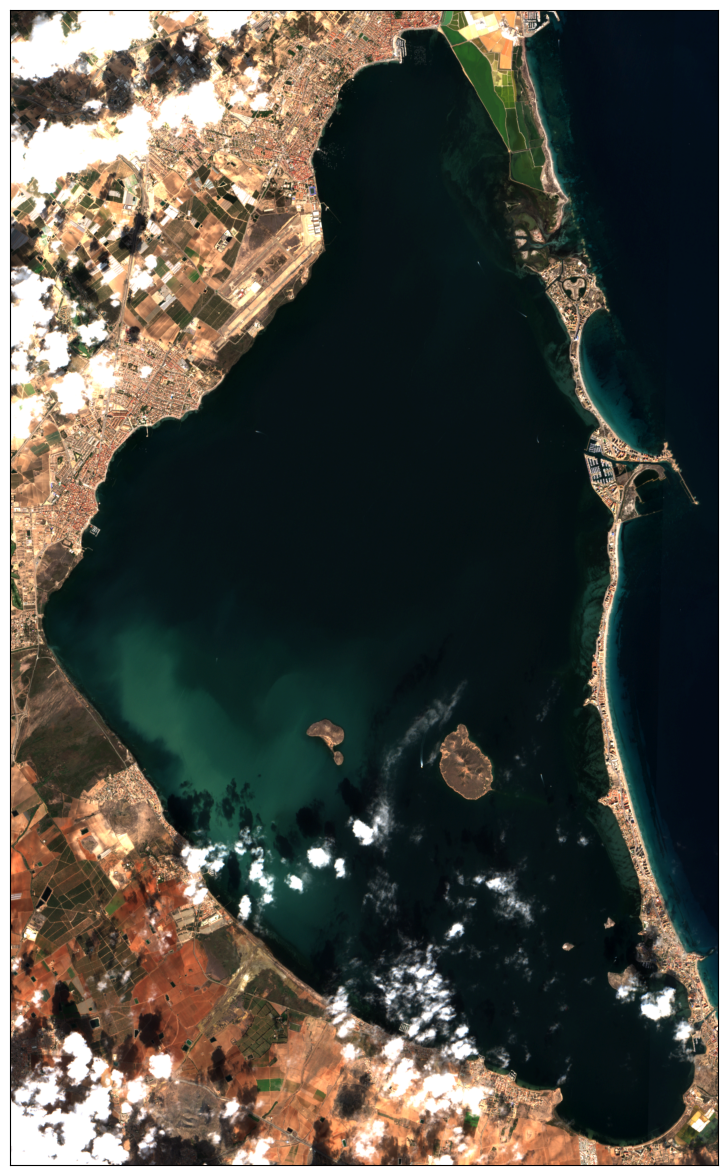

In [111]:
image = Image.open(BytesIO(response.content))
image_np = np.array(image, dtype=np.float32)  # Convert to float for scaling

# Use your `plot_image` function with a brightness factor and clipping range
plot_image(image_np, factor=3.5 / 255, clip_range=(0, 1))